# Multidomain CLARA tutorial: CAT (Cost Additive Trick)

This notebook reproduces the **empirical application** in the MD-CLARA paper (Section 5) for the **CAT** route on the same occupation × seniority dataset as the IDCD and DAT tutorials.

Under CAT, substitution and indel costs are defined **additively** from domain-level costs, then multidomain OM distances are computed. **MD-CLARA** keeps this cost construction unchanged while clustering via CLARA subsamples.

**Diagnostics:** combined state-space summary (CAT still uses combined states internally), leave-one-domain-out stability, cluster quality, and repetition stability.

Cross-strategy comparison: `md_clara_cross_strategy_diagnostics.ipynb`.

## Step 1 — Imports and paths

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sequenzo import *
from sequenzo import SequenceData
from sequenzo.multidomain import (
    get_association_between_domains,
    plot_multidomain_sequence_index_by_cluster,
)
from sequenzo.multidomain.clara import (
    md_clara,
    plot_md_clara_quality,
    plot_dat_domain_contributions,
    leave_one_domain_out_sensitivity,
    plot_leave_one_domain_out_sensitivity,
    summarize_combined_state_space
)

DOMAIN_NAMES = ["occupation", "seniority"]

CLARA_R = 25
CLARA_R_DIAG = 15


def clara_sample_size(n_cases: int, max_k: int = 10) -> int:
    return min(1000, max(40 + 2 * max_k, int(0.4 * n_cases)))


TUTORIAL_SUBSET_N = None
RANDOM_STATE = 42

DATA_DIR = Path("data") # the root path is your jupyter root, not project root
OUTPUT_DIR = Path("output")


## Step 2 — Load and align the two domain datasets

Both CSV files share `worker_id`. We keep the intersection and sort rows so that row *i* in occupation matches row *i* in seniority.

In [2]:
OCCUPATION_CSV = DATA_DIR / "detailed_sequence_10_work_years_df_clean_year_names_column.csv"
SENIORITY_CSV = DATA_DIR / "detailed_senority_levels_for_10_years_clean_year_names_column.csv"

occupation_df = pd.read_csv(OCCUPATION_CSV)
seniority_df = pd.read_csv(SENIORITY_CSV)

# Keep individuals present in both domains and enforce identical row order.
common_ids = np.intersect1d(occupation_df["worker_id"], seniority_df["worker_id"])
occupation_df = (
    occupation_df[occupation_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
seniority_df = (
    seniority_df[seniority_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
assert (occupation_df["worker_id"].values == seniority_df["worker_id"].values).all()

if TUTORIAL_SUBSET_N is not None:
    occupation_df = occupation_df.head(TUTORIAL_SUBSET_N).copy()
    seniority_df = seniority_df.head(TUTORIAL_SUBSET_N).copy()

print(f"Individuals: {len(occupation_df):,}")
occupation_df.head()


Individuals: 32,628


,worker_id,gender,country,cohort,1,2,3,4,5,6,7,8,9,10
0,%C2%BBkiran-mummala-narayana-68aaba89,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
1,%E2%86%92-jeremy-mikkola-14455832,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
2,%E2%97%8F%E0%B9%8B-b%C3%A1%DA%A9t%C3%BD%C3%A1v...,male,india,11-20 total work years,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science
3,%E5%A4%A7%E4%BB%BB-%E9%99%B3-880a24110,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
4,%EF%BF%BDgary-m-762b16b8,male,us,21-30 total work years,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware


## Step 3 — Color palettes

We reuse the custom state colors from the original LinkedIn sequence-analysis notebook (`250814.ipynb`) so occupation and seniority index plots stay visually consistent.

In [4]:
# Color palettes from the original LinkedIn sequence-analysis notebook (250814.ipynb).
# One hex code per state, in the same order as OCCUPATION_STATES / SENIORITY_STATES.

OCCUPATION_COLORS = [
    "#659F9F",  # Data
    "#4CA7A7",  # Data science
    "#6BB8C8",  # Software
    "#8CC9E0",  # Hardware
    "#B2C95E",  # Systems & infrastructure
    "#D7D97F",  # Research
    "#E8E1B4",  # Support & test
]

SENIORITY_COLORS = [
    "#E7D4EA",  # Assistant/Junior
    "#D8898C",  # Regular
    "#E14C48",  # Senior
    "#A64F91",  # Leader
    "#6A3D8C",  # Chief/founder
]


## Step 4 — Build `SequenceData` objects

Each domain is a wide table: one row per worker, columns `1`…`10` for years. The state lists follow the cleaned labels from the original analysis notebook.

In [5]:
TIME_COLS = [str(i) for i in range(1, 11)]

OCCUPATION_STATES = [
    "Data",
    "Data science",
    "Software",
    "Hardware",
    "Systems & infrastructure",
    "Research",
    "Support & test",
]
SENIORITY_STATES = [
    "Assistant/Junior",
    "Regular",
    "Senior",
    "Leader",
    "Chief/founder",
]

occupation_seq = SequenceData(
    data=occupation_df,
    id_col="worker_id",
    time=TIME_COLS,
    states=OCCUPATION_STATES,
    custom_colors=OCCUPATION_COLORS,
)

seniority_seq = SequenceData(
    data=seniority_df,
    id_col="worker_id",
    time=TIME_COLS,
    states=SENIORITY_STATES,
    custom_colors=SENIORITY_COLORS,
)

domains = [occupation_seq, seniority_seq]
domain_names = ["occupation", "seniority"]

print(f"Domain 1 (occupation): {occupation_seq.seqdata.shape[0]:,} sequences")
print(f"Domain 2 (seniority):  {seniority_seq.seqdata.shape[0]:,} sequences")


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Labels: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Void: '%' (not in states (inactive); not observed in data) — out-of-window padding; SAMM/seqsamm drops subsequences containing void
[>] Weights: Not provided
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Assistant/Junior', 'Re

## Step 5 — Explore each domain separately (optional)

Quick sanity check: plot the marginal sequence index for each domain.

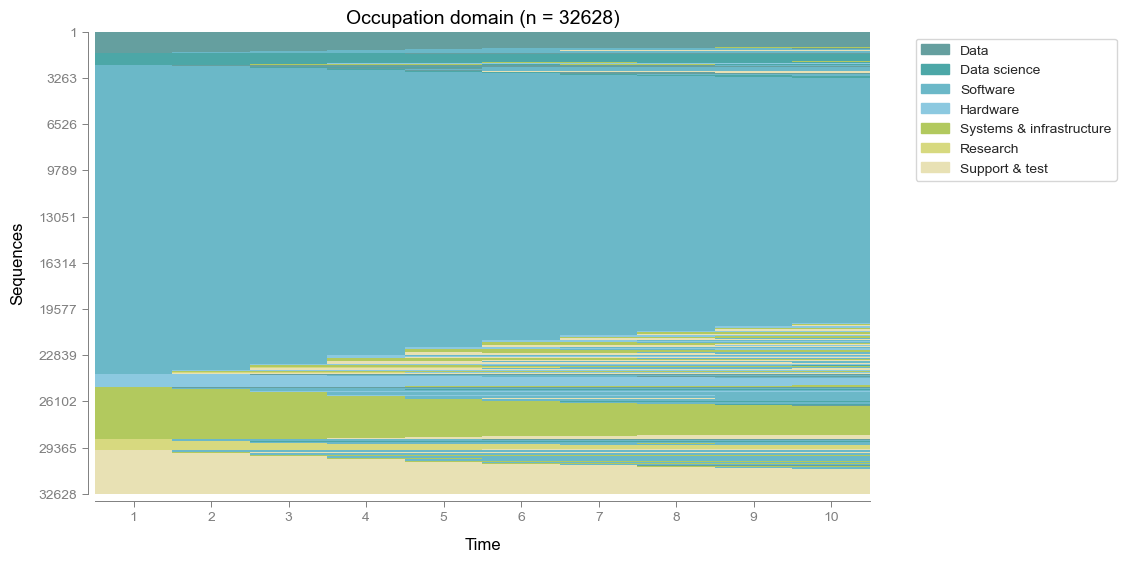

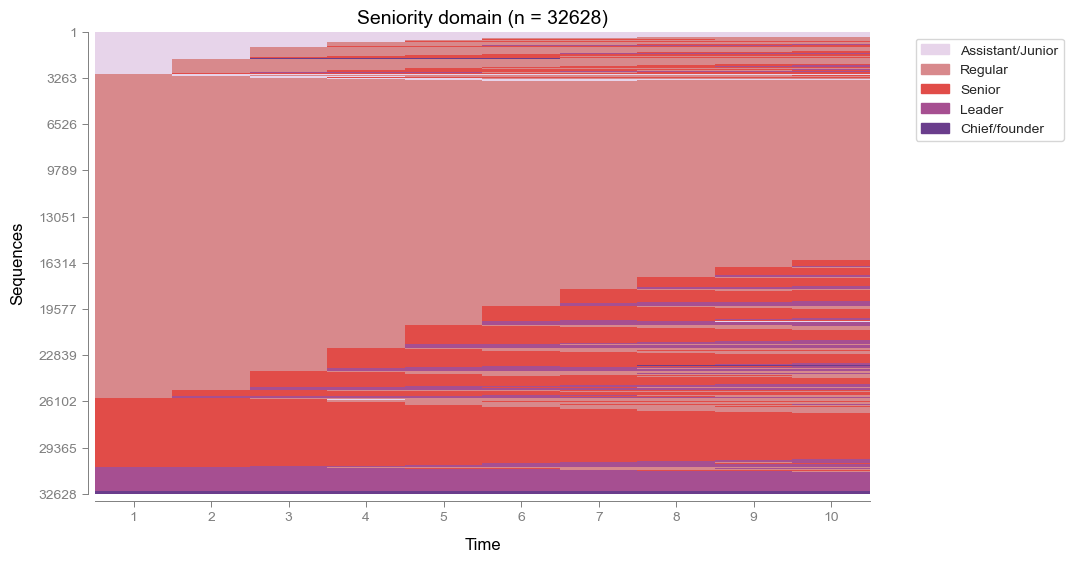

In [6]:
# Uncomment to plot the full sample (can be slow with ~32k rows).
plot_sequence_index(seqdata=occupation_seq, title="Occupation domain")
plot_sequence_index(seqdata=seniority_seq, title="Seniority domain")


## Step 6 — Measure association between domains

CAT assumes **state independence across domains** at each time point. Strong association does not forbid CAT, but you should interpret results with that assumption in mind (Ritschard et al., 2023).

In [9]:
# Optional but recommended: check whether the two domains are associated
# before interpreting a joint multidomain typology.
assoc = get_association_between_domains(
    domains,
    assoc=("LRT", "V"),
    dnames=domain_names,
    explain=True,
)
assoc



📜 Full results table:


,df,LRT,p(LRT),v,p(v),strength
occupation vs seniority,24.0,17434.505964,0.000 ***,0.141299,0.000 ***,Weak



📘 Column explanations:
  - df       : Degrees of freedom for the test (typically 1 for binary state sequences).
  - LRT      : Likelihood Ratio Test statistic (higher = stronger dependence).
  - p(LRT)   : p-value for LRT + significance stars: * (p<.05), ** (p<.01), *** (p<.001)
  - v        : Cramer's V statistic (0 to 1, measures association strength).
  - p(v)     : p-value for Cramer's V (based on chi-squared test) + significance stars: * (p<.05), ** (p<.01), *** (p<.001)
  - strength : Qualitative label for association strength based on Cramer's V:
               0.00-0.09 -> None, 0.10-0.29 -> Weak, 0.30-0.49 -> Moderate, >=0.50 -> Strong


## Step 7 — Combined multidomain state space

CAT builds multidomain costs from domain-level costs; summarizing the observed combined-state alphabet helps assess sparsity (same helper as IDCD).

In [10]:
state_space = summarize_combined_state_space(domains, ch_sep="+")
pd.DataFrame([{k: state_space[k] for k in (
    "theoretical_combined_states", "observed_combined_states",
    "coverage", "rare_state_share",
)}])


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Software+Regular', 'Software+Senior', 'Systems & infrastructure+Regular', 'Support & test+Regular', 'Software+Leader', 'Data+Regular', 'Systems & infrastructure+Senior', 'Support & test+Senior', 'Support & test+Leader', 'Data science+Regular', 'Hardware+Regular', 'Software+Assistant/Junior', 'Systems & infrastructure+Leader', 'Data+Senior', 'Research+Regular', 'Hardware+Leader', 'Hardware+Senior', 'Data+Leader', 'Data science+Senior', 'Research+Assistant/Junior', 'Hardware+Assistant/Junior', 'Data science+Leader', 'Systems & infrastructure+Assistant/Junior', 'Software+Chief/founder', 'Support & test+Assistant/Junior', 'Research+Senior', 'Systems & infrastructure+Chief/founder', 'Data+Assistant/J

,theoretical_combined_states,observed_combined_states,coverage,rare_state_share
0,35,35,1.0,0.0


## Step 8 — Configure CAT distance parameters

Under CAT, OM costs are built **per domain** and then summed across domains.

We use classical OM(1,2): constant substitution cost 2 (via `sm='CONSTANT'`), indel cost 1, no normalization. Equal domain weights are the default.

In [11]:
N_DOMAINS = len(domains)

distance_params = {
    "method": "OM",
    "sm": ["CONSTANT"] * N_DOMAINS,  # one spec per domain
    "indel": 1,
    "norm": "none",
}

distance_params


{'method': 'OM', 'sm': ['CONSTANT', 'CONSTANT'], 'indel': 1, 'norm': 'none'}

## Step 9 — Run MD-CLARA with `strategy='cat'`

MD-CLARA avoids storing the full `N × N` distance matrix. It repeatedly:

1. Draws a subsample of size `sample_size`
2. Searches for medoids on that subsample
3. Assigns all sequences to the chosen medoids

Set `TUTORIAL_SUBSET_N` in Step 1 to e.g. `2000` if you want a faster first run.

In [18]:
N = occupation_seq.seqdata.shape[0]
sample_size = clara_sample_size(N, max_k=10)
print(f"N = {N:,} | b = {sample_size} | R = {CLARA_R}")

result = md_clara(
    domains,
    strategy="cat",
    distance_params=distance_params,
    R=CLARA_R,
    sample_size=None,
    kvals=list(range(2, 11)),
    criteria=("distance",),
    stability=True,
    combined_state_space=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=True,
)

result.stats


N = 32,628 | b = 1000 | R = 10
[>] 2 domains with 7055 sequences.
[>] Building MD sequences of combined states.
  - OK.
[>] Computing substitution cost matrix for domain 0.
[>] Computing substitution cost matrix for domain 1.
[>] Computing MD substitution and indel costs with additive trick.
  - OK.
[>] Starting multidomain CLARA with distance provider.
  - Strategy sample size: 60, iterations: 10
  - Within-subsample storage: condensed; medoid cache: False
[>] Running CLARA iterations...
  - Done.
[>] Aggregating iterations for each k...
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Software+Regular', 'Software+Senior', 'Systems & infrastructure+Regular', 'Support & test+Regular', 'Software+Leader', 'Data+Regular', 'Systems & infrastructur

,k,total_diss,avg_dist,pbm,db,xb,ams,ari08,jc08,best_iter,criterion,R,sample_size,strategy
0,2,455768.0,13.968616,1.850122,0.891112,0.367595,0.554932,0.0,0.0,4.0,distance,10,60,cat
1,3,411764.0,12.619958,0.806491,1.747676,1.051663,0.437634,0.0,0.0,8.0,distance,10,60,cat
2,4,388460.0,11.905725,0.509714,1.663676,1.190573,0.348456,0.0,0.0,2.0,distance,10,60,cat
3,5,354434.0,10.862879,0.391857,1.766513,1.086288,0.392332,0.0,0.0,3.0,distance,10,60,cat
4,6,347684.0,10.656001,0.317040,1.607610,1.065600,0.385566,0.0,0.0,3.0,distance,10,60,cat
5,7,325916.0,9.988844,0.265081,1.590831,0.624303,0.469370,0.0,0.0,0.0,distance,10,60,cat
6,8,308692.0,9.460954,0.226233,1.489247,0.946095,0.417171,0.0,0.0,3.0,distance,10,60,cat
7,9,297482.0,9.117384,0.237626,1.481125,0.911738,0.412323,0.0,0.0,3.0,distance,10,60,cat
8,10,295854.0,9.067488,0.194601,1.657224,0.906749,0.409514,0.0,0.0,3.0,distance,10,60,cat


## Step 10 — Inspect cluster quality and stability

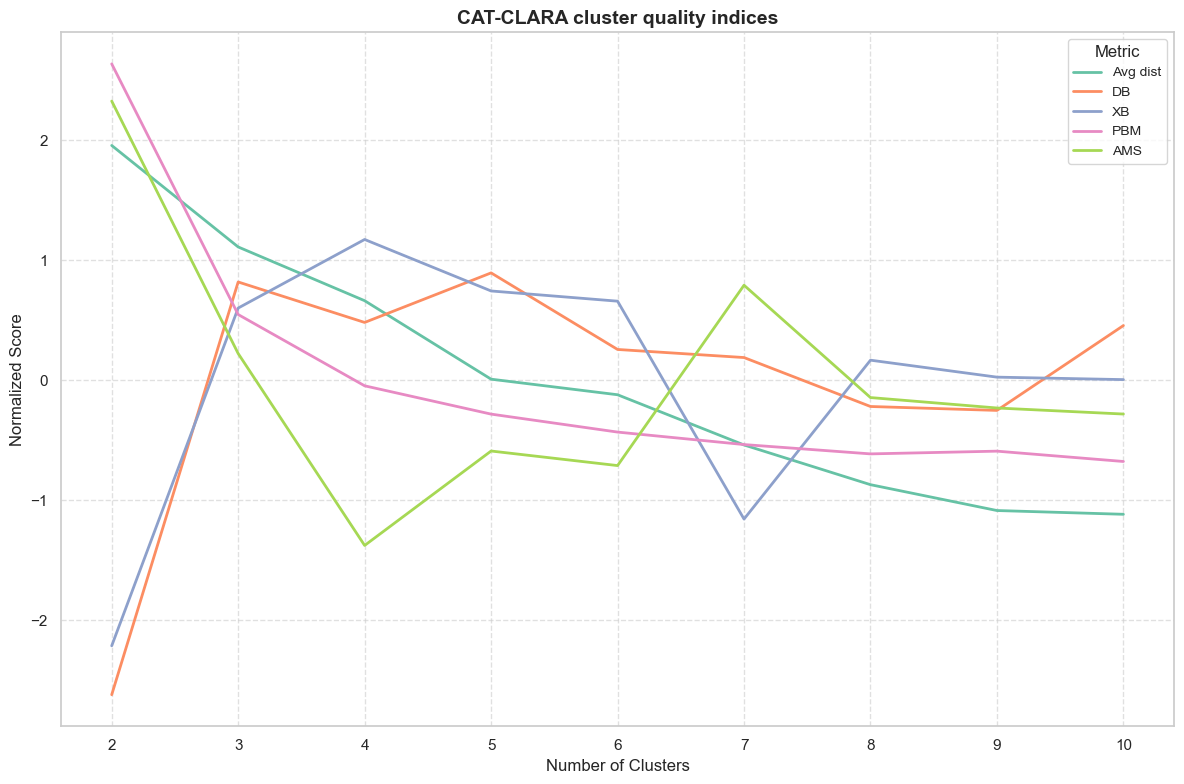

In [19]:
plot_md_clara_quality(
    result,
    title="CAT-CLARA cluster quality indices",
    save_as=str(OUTPUT_DIR / "cat_clara_quality.png"),
)


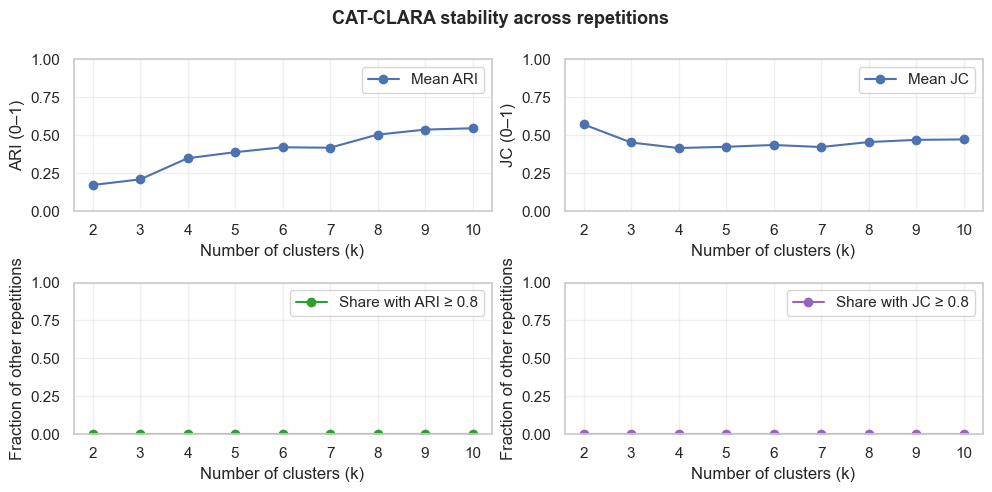

In [20]:
if result.stability:
    from sequenzo.multidomain.clara import plot_md_clara_stability
    plot_md_clara_stability(
        result,
        title="CAT-CLARA stability across repetitions",
        save_as=str(OUTPUT_DIR / "cat_clara_stability.png"),
    )


## Step 11 — Choose k and inspect cluster labels

In [21]:
# Helper: pick k with the lowest average distance (simple heuristic).
best_k = int(result.stats.loc[result.stats["avg_dist"].idxmin(), "k"])
print(f"Suggested k (lowest avg_dist): {best_k}")

labels = result.best_clustering(best_k)

# Cluster labels are stored with worker_id as the row index.
clustering_df = result.clustering.reset_index().rename(columns={"index": "worker_id"})
cluster_col = f"Cluster {best_k}"
clustering_df["cluster"] = clustering_df[cluster_col]
clustering_df.head()


Suggested k (lowest avg_dist): 10


,worker_id,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,cluster
0,%C2%BBkiran-mummala-narayana-68aaba89,2,1,4,2,2,5,2,2,2,2
1,%E2%86%92-jeremy-mikkola-14455832,2,1,4,2,2,5,2,2,2,2
2,%E2%97%8F%E0%B9%8B-b%C3%A1%DA%A9t%C3%BD%C3%A1v...,1,2,2,5,6,7,8,9,10,10
3,%E5%A4%A7%E4%BB%BB-%E9%99%B3-880a24110,1,1,1,5,6,7,8,9,10,10
4,%EF%BF%BDgary-m-762b16b8,2,1,3,2,2,5,5,5,6,6


## Step 12 — Sequence index plots coloured by cluster

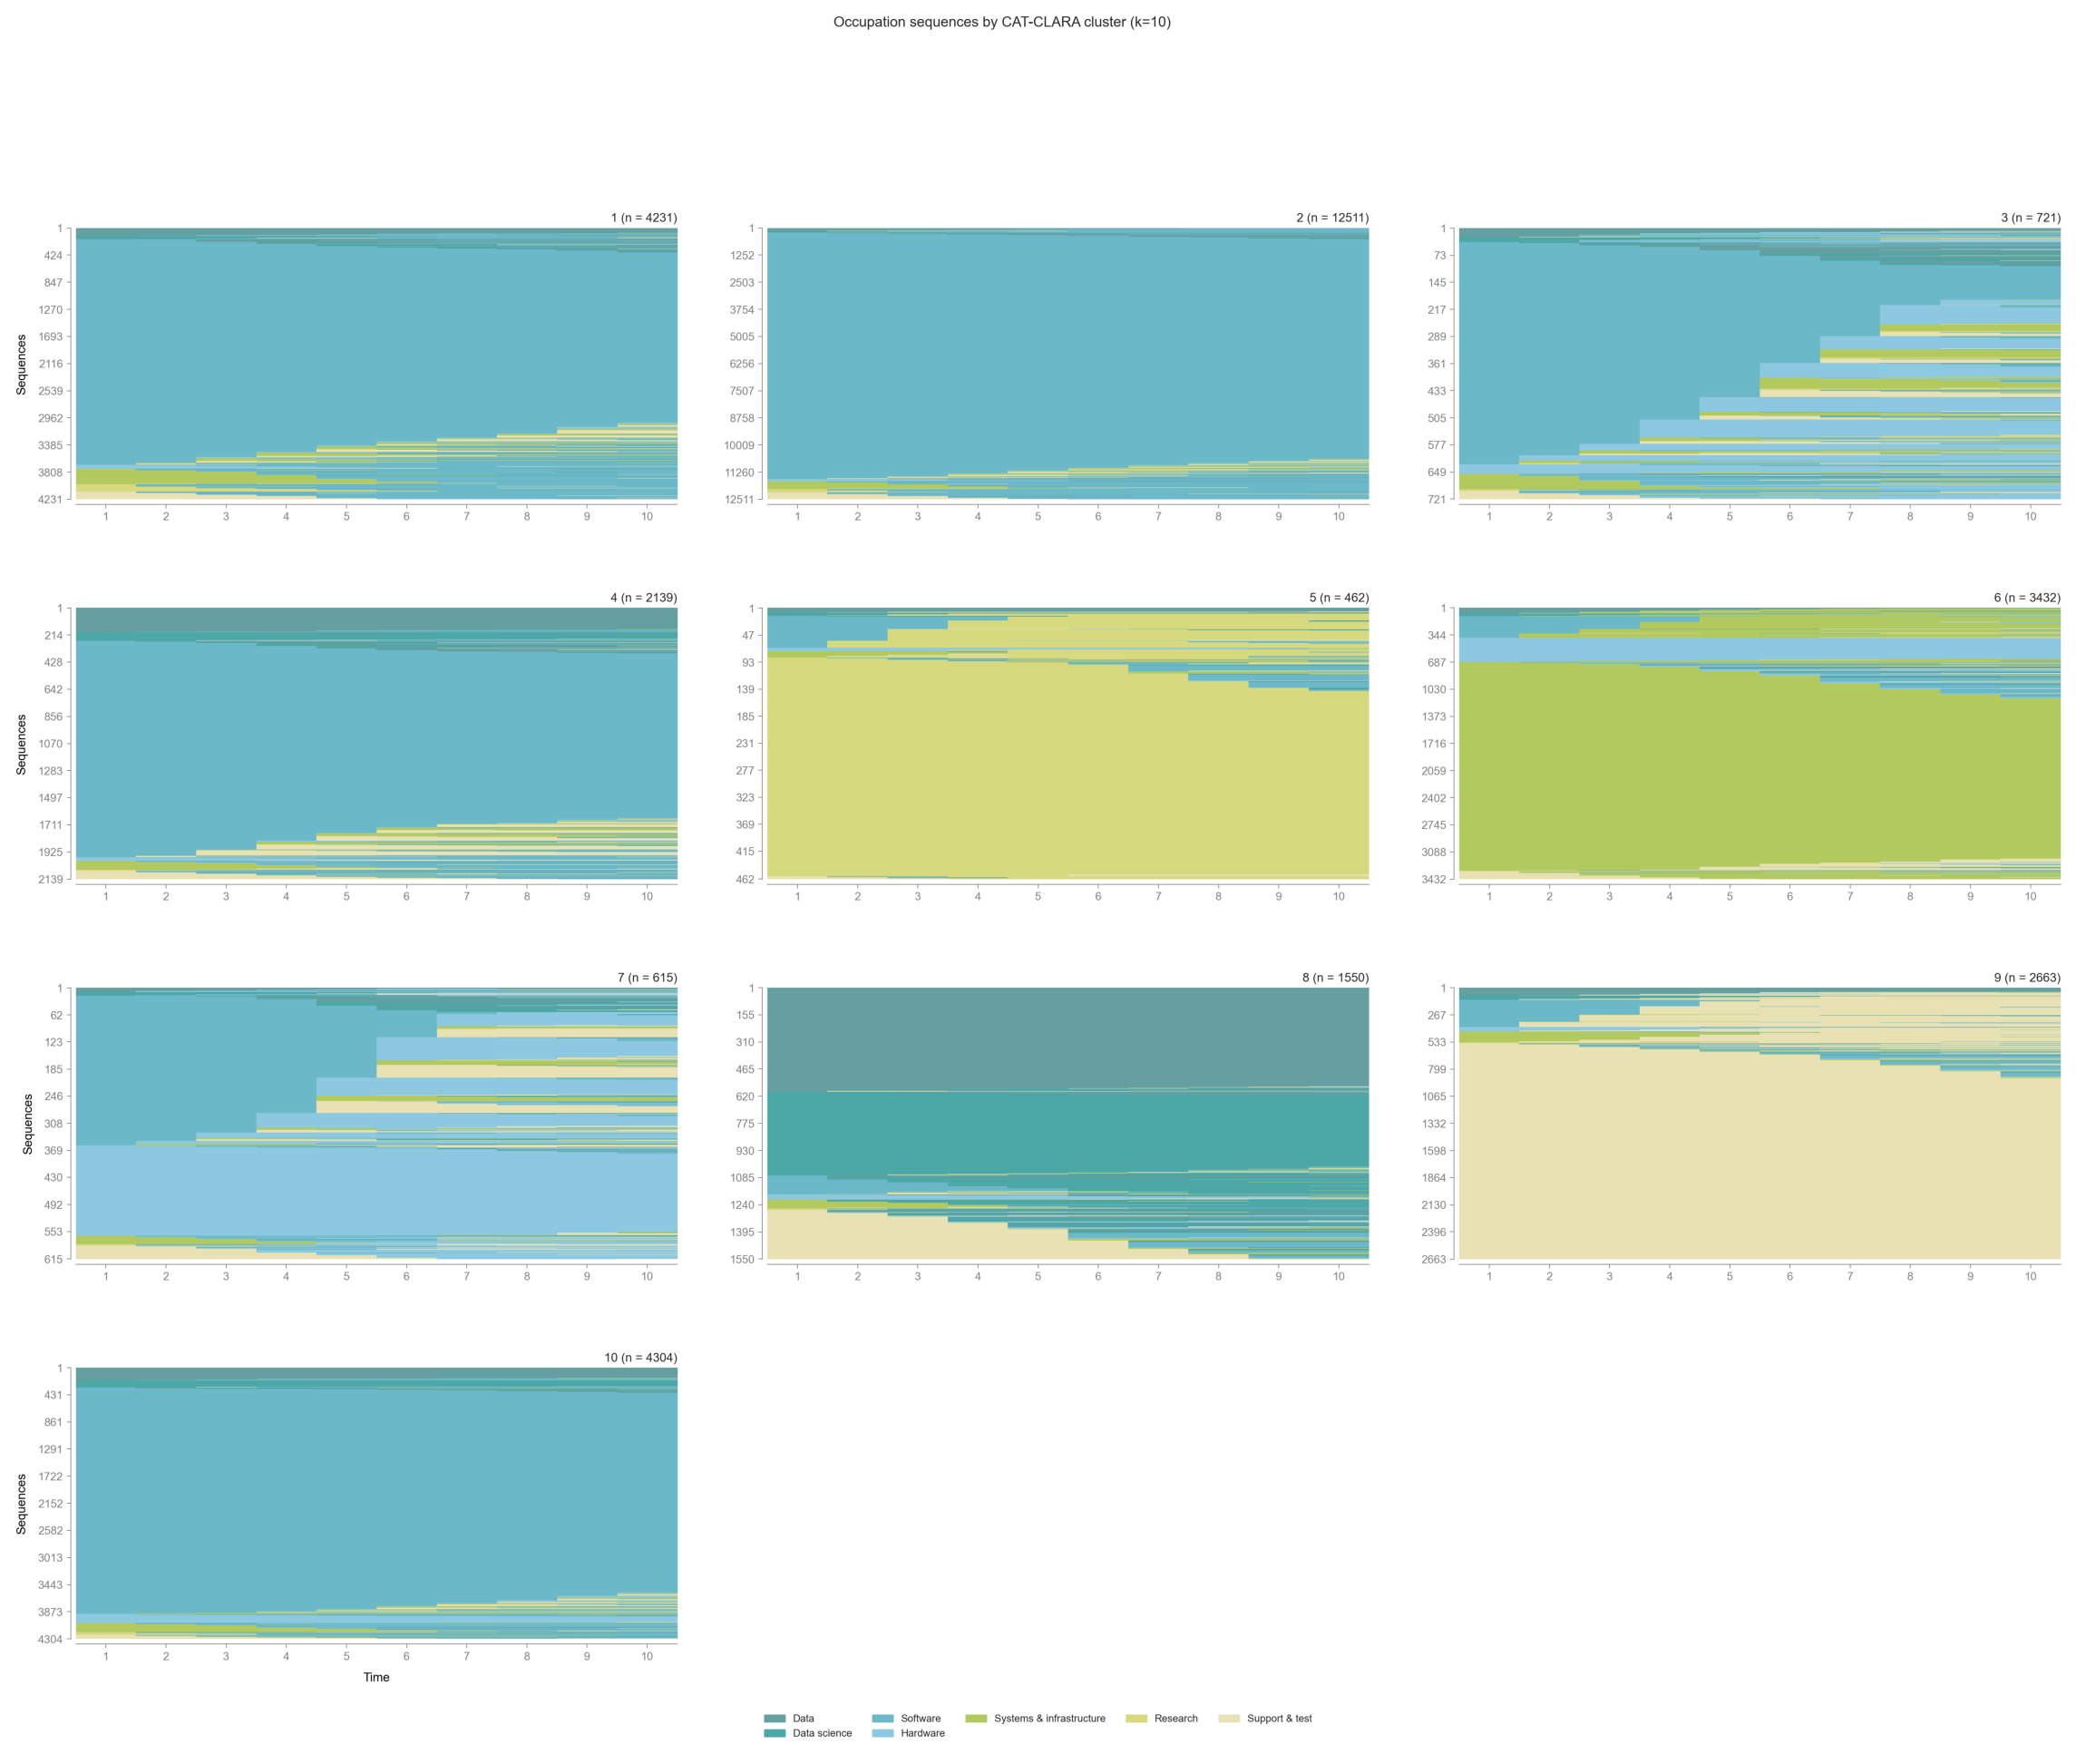

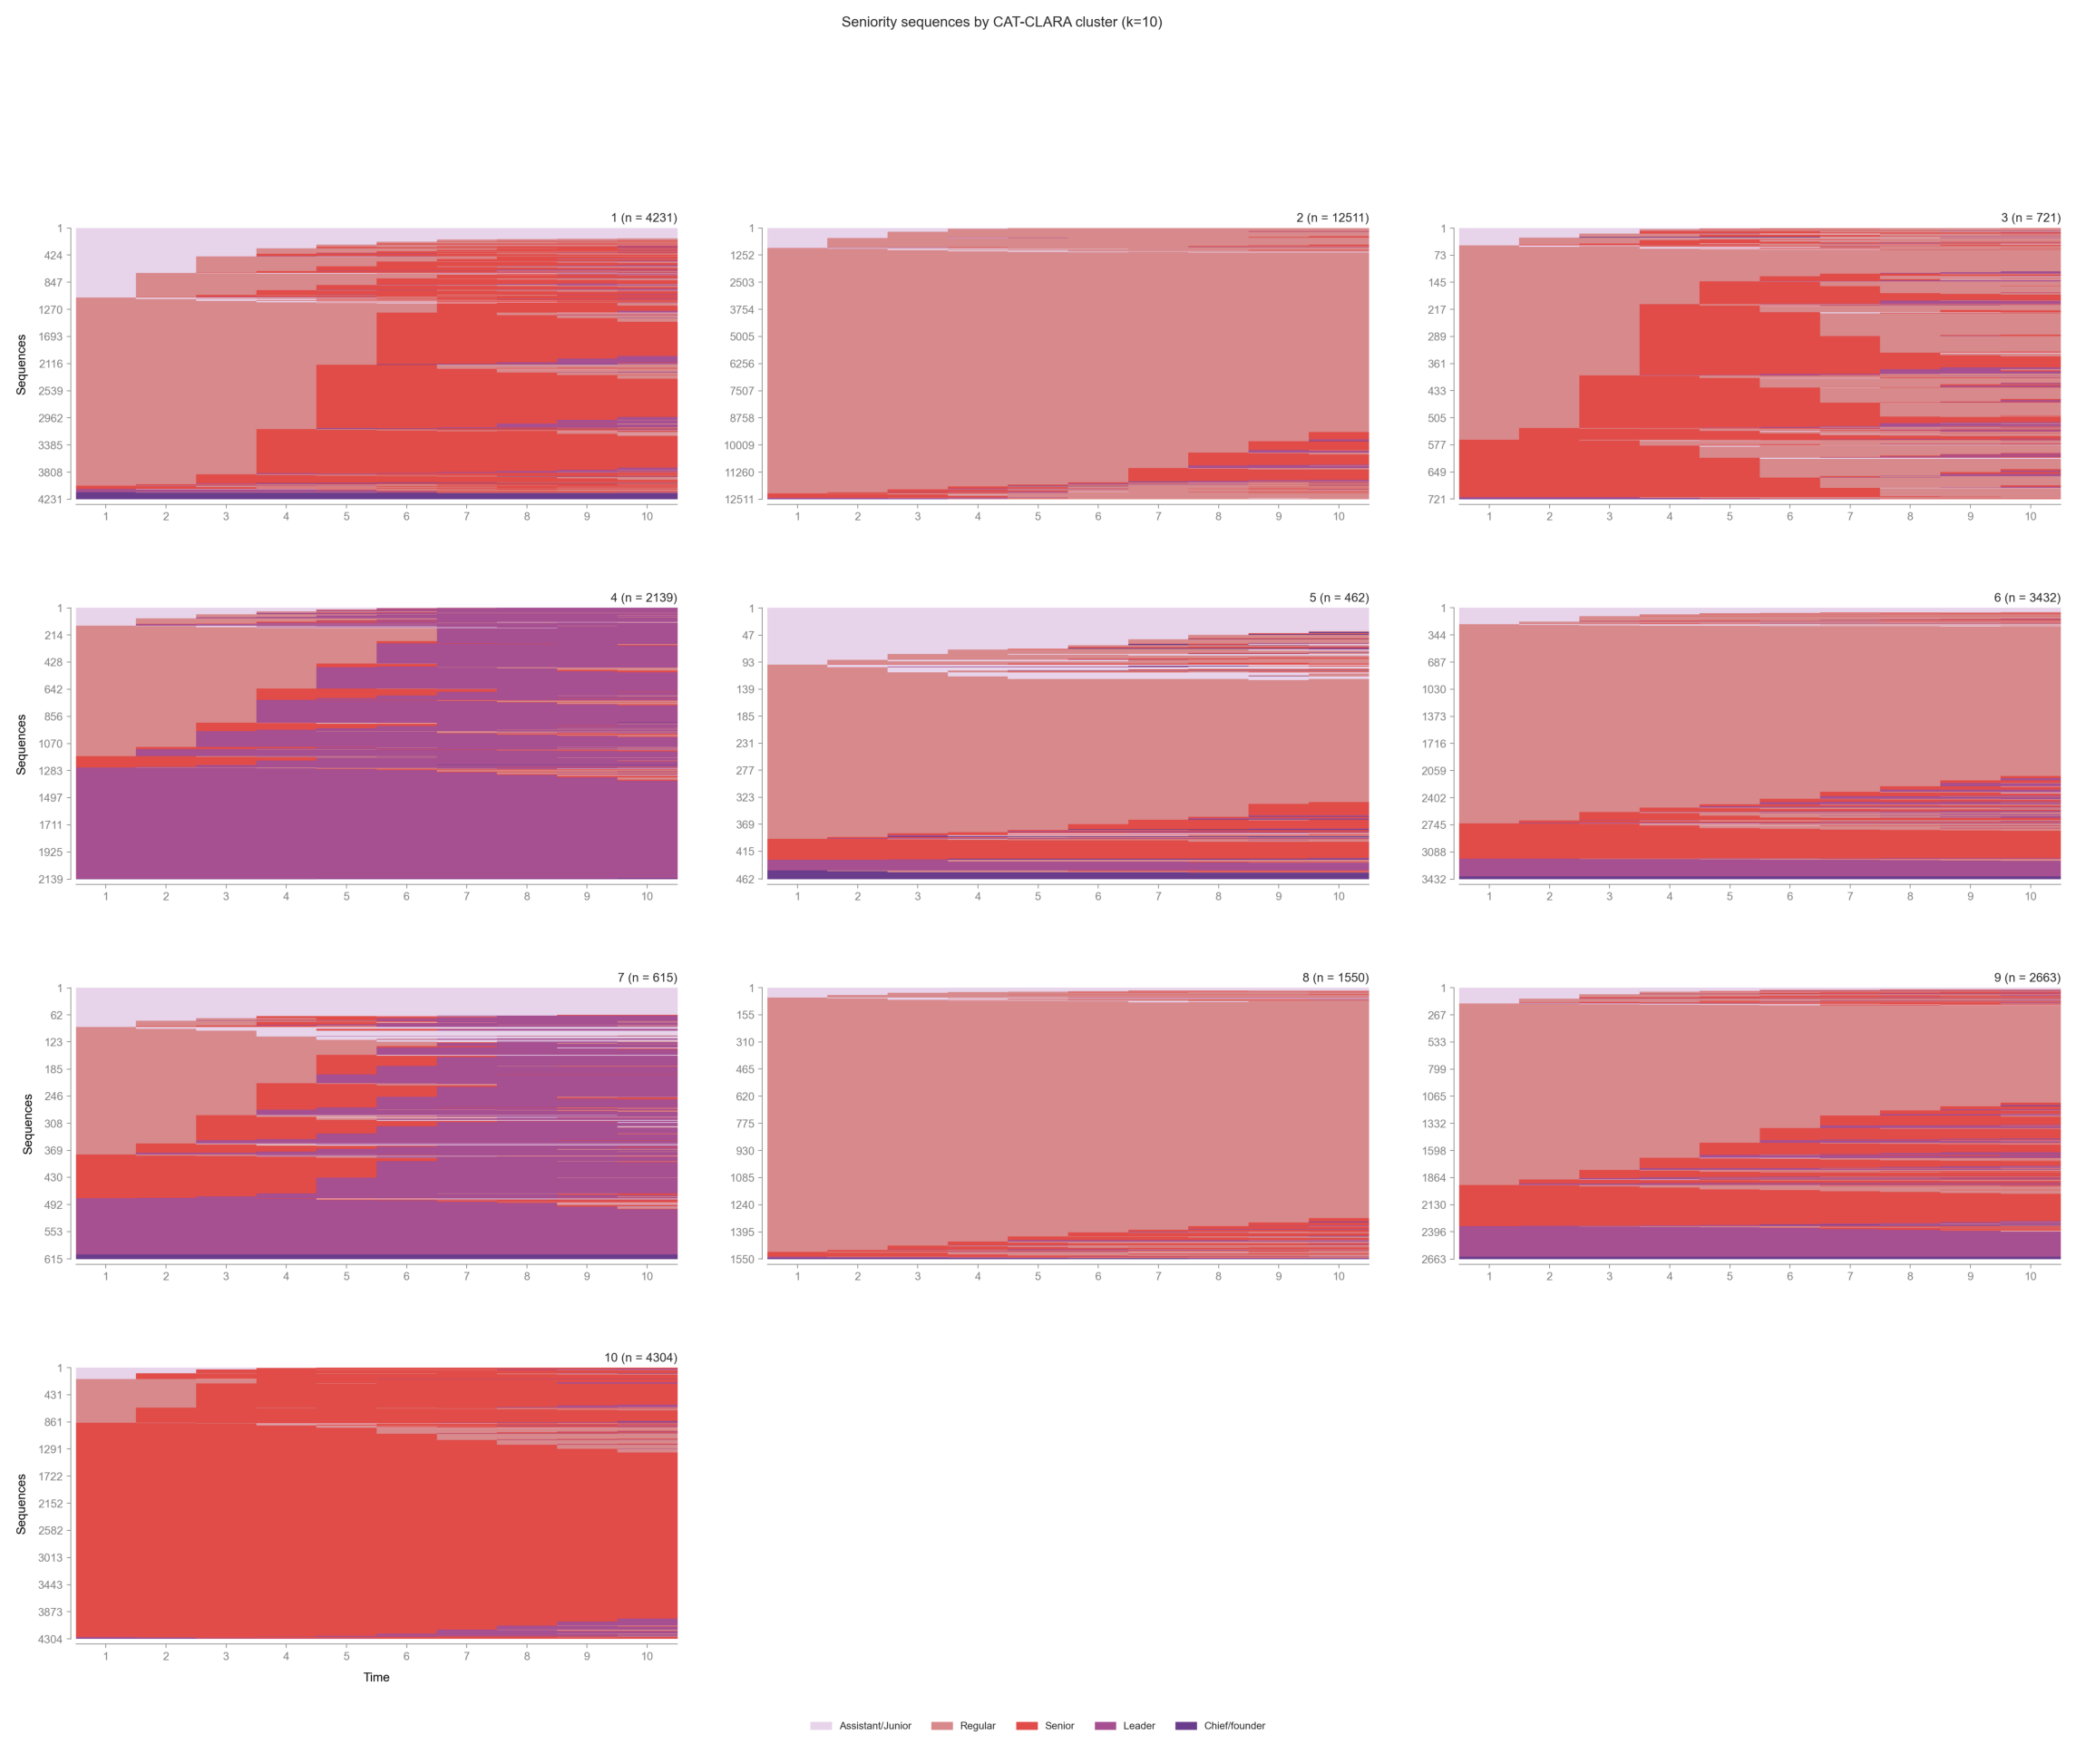

In [22]:
# Sequence index plots by cluster (one domain at a time).
plot_df = occupation_df.merge(
    clustering_df[["worker_id", "cluster"]],
    on="worker_id",
    how="left",
).rename(columns={"worker_id": "Entity ID", "cluster": "Cluster"})

plot_sequence_index(
    seqdata=occupation_seq,
    group_dataframe=plot_df,
    group_column_name="Cluster",
    title=f"Occupation sequences by CAT-CLARA cluster (k={best_k})",
)

plot_sequence_index(
    seqdata=seniority_seq,
    group_dataframe=plot_df,
    group_column_name="Cluster",
    title=f"Seniority sequences by CAT-CLARA cluster (k={best_k})",
)


## Leave-one-domain-out stability

Re-fit MD-CLARA after omitting one domain at a time and compare partitions to the **all-domain** solution (ARI). Low agreement suggests the omitted domain carries distinctive typological information. Uses `CLARA_R_DIAG` repetitions to keep runtime manageable.

With **two domains**, omitting one leaves a single domain; Sequenzo then fits standard single-domain CLARA (`reduced_model='clara_single_domain'`) for that row. ARI still compares partitions on the same individuals.

In [23]:
loo = leave_one_domain_out_sensitivity(
    domains,
    strategy="cat",
    k=best_k,
    R=CLARA_R_DIAG,
    sample_size=sample_size,
    distance_params=distance_params,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=True,
)
loo["domain"] = [DOMAIN_NAMES[i] for i in loo["omitted_domain_index"]]
loo


[>] 2 domains with 7055 sequences.
[>] Building MD sequences of combined states.
  - OK.
[>] Computing substitution cost matrix for domain 0.
[>] Computing substitution cost matrix for domain 1.
[>] Computing MD substitution and indel costs with additive trick.
  - OK.
[>] Starting multidomain CLARA with distance provider.
  - Strategy sample size: 1000, iterations: 10
  - Within-subsample storage: condensed; medoid cache: False
[>] Running CLARA iterations...
  - Done.
[>] Aggregating iterations for each k...
[>] Starting generalized CLARA for sequence analysis.
[>] Using crisp clustering optimizing the following criterion: distance.
  - Aggregating 32628 sequences...
  - OK (1745 unique cases).
[>] Starting iterations...
  - Done.
[>] Aggregating iterations for each k values...
  - Done.
[>] Starting generalized CLARA for sequence analysis.
[>] Using crisp clustering optimizing the following criterion: distance.
  - Aggregating 32628 sequences...
  - OK (2006 unique cases).
[>] Start

,omitted_domain,omitted_domain_index,strategy,k,ari_vs_all_domains,jaccard_vs_all_domains,full_requested_sample_size,full_effective_sample_size,full_n_unique_profiles,reduced_requested_sample_size,reduced_effective_sample_size,reduced_n_unique_profiles,reduced_model,domain
0,domain_0,0,cat,10,0.448800,0.389295,1000,1000,7055,1000,1000,None,clara_single_domain,occupation
1,domain_1,1,cat,10,0.252871,0.272342,1000,1000,7055,1000,1000,None,clara_single_domain,seniority


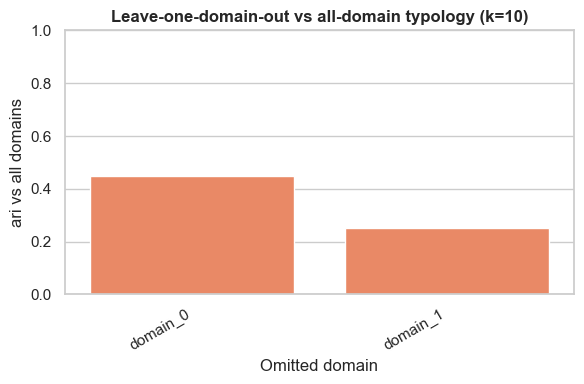

In [24]:
STRATEGY_TAG = "cat"
plot_leave_one_domain_out_sensitivity(
    loo,
    metric="ari_vs_all_domains",
    title=f"Leave-one-domain-out vs all-domain typology (k={best_k})",
    save_as=str(OUTPUT_DIR / f"cat_loo_sensitivity_k{best_k}.png"),
)
plt.show()


## Step 13 — Save results

In [25]:
result.stats.to_csv(OUTPUT_DIR / "cat_clara_stats.csv", index=False)
clustering_df.to_csv(OUTPUT_DIR / f"cat_clara_clustering_k{best_k}.csv", index=False)
print("Saved outputs to", OUTPUT_DIR)
loo.to_csv(OUTPUT_DIR / f"cat_loo_sensitivity_k{best_k}.csv", index=False)


Saved outputs to output


---

### What you learned

- **CAT** builds multidomain substitution/indel costs **additively** from domain-level costs.
- **MD-CLARA** keeps this cost construction while using CLARA subsampling for scalability.
- Combined-state sparsity can be summarized before clustering (same helper as IDCD).
- **Leave-one-domain-out** diagnostics complement cluster-quality and stability plots.
- Cross-strategy comparison: `md_clara_cross_strategy_diagnostics.ipynb`.
- See `dat_md_clara_tutorial.ipynb` for the **DAT** route on the same data.